In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import sys
import os

# Menambahkan path src agar dapat mengimpor preprocessing
sys.path.append(os.path.abspath('..'))
from src.preprocessing import apply_urgency_labels

# Konfigurasi plot
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [ ]:
data_path = '../data/raw/complaints-2026-05-20_09_21.csv'
df = pd.read_csv(data_path)
print(f"Total baris awal: {len(df)}")


Total baris awal: 53928


In [ ]:
# label Urgency 
df = apply_urgency_labels(df)
print(df['Urgency'].value_counts())


Urgency
Medium    20953
High      20771
Low       12204
Name: count, dtype: int64


In [4]:
# Menangani nilai kosong dan menyederhanakan respons publik
df['Company public response'] = df['Company public response'].fillna('No Response')

# Mengkategorikan respons standar agar lebih mudah dianalisis
def categorize_response(resp):
    if resp == 'No Response':
        return resp
    elif 'chooses not to provide a public response' in resp:
        return 'Standard/No Public Response'
    elif 'acted appropriately as authorized by contract or law' in resp:
        return 'Acted Appropriately'
    elif 'disputes the facts' in resp:
        return 'Disputes Facts'
    elif 'opportunity to answer' in resp:
        return 'Opportunity to Answer'
    elif 'can\'t verify or dispute' in resp:
        return 'Cannot Verify'
    elif 'isolated error' in resp:
        return 'Isolated Error'
    elif 'misunderstanding' in resp:
        return 'Misunderstanding'
    else:
        return 'Other'

df['Public_Response_Category'] = df['Company public response'].apply(categorize_response)
print(df['Public_Response_Category'].value_counts())


Public_Response_Category
No Response                    32590
Standard/No Public Response    17842
Acted Appropriately             2767
Disputes Facts                   206
Opportunity to Answer            190
Cannot Verify                    125
Other                             99
Isolated Error                    57
Misunderstanding                  52
Name: count, dtype: int64


In [ ]:
# tabel kontingensi
crosstab = pd.crosstab(df['Public_Response_Category'], df['Urgency'])
print("Tabel Kontingensi:")
display(crosstab)

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

# Cramer's V
n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
print(f"Cramer's V: {cramer_v:.4f}")


Tabel Kontingensi:


Urgency,High,Low,Medium
Public_Response_Category,,,
Acted Appropriately,962,435,1370
Cannot Verify,47,22,56
Disputes Facts,87,32,87
Isolated Error,13,24,20
Misunderstanding,26,12,14
No Response,12675,7101,12814
Opportunity to Answer,60,32,98
Other,45,15,39
Standard/No Public Response,6856,4531,6455


Chi-Square Statistic: 298.1359
P-value: 6.2032e-54
Cramer's V: 0.0526


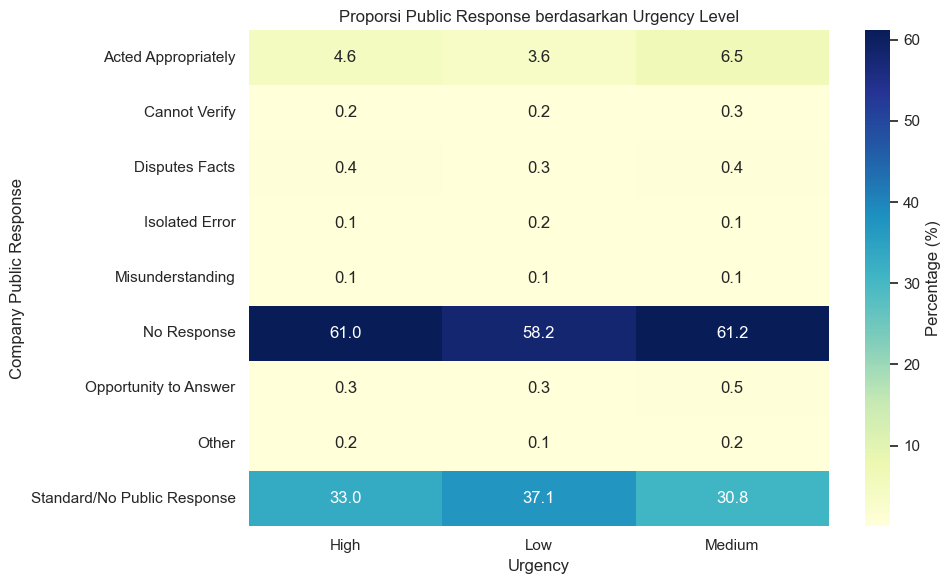

In [6]:
# Visualisasi dengan Heatmap
# Menghitung persentase berdasarkan kolom (Urgency) untuk melihat proporsi respons per level urgency
crosstab_pct = crosstab.div(crosstab.sum(axis=0), axis=1) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'})
plt.title('Proporsi Public Response berdasarkan Urgency Level')
plt.ylabel('Company Public Response')
plt.xlabel('Urgency')
plt.tight_layout()
plt.show()
